# Rabbits and foxes

There are initially 400 rabbits and 200 foxes on a farm (but it could be two cell types in a 96 well plate or something, if you prefer bio-engineering analogies). Plot the concentration of foxes and rabbits as a function of time for a period of up to 600 days. The predator-prey relationships are given by the following set of coupled ordinary differential equations:

\begin{align}
\frac{dR}{dt} &= k_1 R - k_2 R F \tag{1}\\
\frac{dF}{dt} &= k_3 R F - k_4 F \tag{2}\\
\end{align}

* Constant for growth of rabbits $k_1 = 0.015$ day<sup>-1</sup>
* Constant for death of rabbits being eaten by foxes $k_2 = 0.00004$ day<sup>-1</sup> foxes<sup>-1</sup>
* Constant for growth of foxes after eating rabbits $k_3 = 0.0004$ day<sup>-1</sup> rabbits<sup>-1</sup>
* Constant for death of foxes $k_4 = 0.04$ day<sup>-1</sup>

*This problem is based on one from Chapter 1 of H. Scott Fogler's textbook "Essentials of Chemical Reaction Engineering".*


In [64]:
%matplotlib inline
import numpy as np
from matplotlib import pyplot as plt

# Now let's try some Kinetic Monte Carlo

We wish to implement a Kinetic Monte Carlo algorithm to simulate the same situation. See https://en.wikipedia.org/wiki/Kinetic_Monte_Carlo for details.

We'll assume the numbers of rabbits and foxes (starting at 400 and 200) are actual rabbits and foxes, not "rabbit densities" for example, and so must always remain integers: you can't have half a rabbit or half a fox.

There are four events, with rates that are straightforward to calculate, so the rejection-free algorithm is suitable:
* `rabbit_birth = k1 * rabbits`
* `rabbit_death = k2 * rabbits * foxes`
* `fox_birth = k3 * rabbits * foxes`
* `fox_death = k4 * foxes`


Use a Kinetic Monte Carlo simulation(s) running for 600 days to determine
1. The expected location of the second peak in foxes (eg. 425 days, 2800 foxes), on occasions that there is one (eg. if there's a peak that's  >200 days and >100 foxes)
2. The interquartile range of the second peak in foxes (eg. 411-443 days, 2700-3120 foxes).
3. The probability that the foxes die out before 600 days are complete


Make sure you've done enough simulations to be suitably confident in your answers (given the precision you think appropriate).

# Your turn!

In [ ]:
k1 = 0.015      # rabbit birth rate (per day)
k2 = 0.00004    # rabbit death rate due to predation (per day per fox)   <-- k2 = rabbit death
k3 = 0.0004     # fox birth rate from predation (per day per rabbit)     <-- k3 = fox birth
k4 = 0.04       # fox natural death rate (per day)

R0, F0 = 400, 200       # initial integers
T_END = 600.0
N_RUNS = 

# We'll analyze/plot on a uniform time grid:
times = np.linspace(0.0, T_END, 1201)   # 0.5-day spacing


# --- event-driven KMC (single run) ---
time = 0.0
rabbit, fox = int(R0), int(F0)

T  = [time]
R  = [rabbit]
F  = [fox]


In [66]:
# storage on the uniform grid
R_grid = np.zeros((N_RUNS, len(times)), dtype=float)
F_grid = np.zeros((N_RUNS, len(times)), dtype=float)

# per-run maxima (value + time on the uniform grid)
maxR_vals, maxR_times = [], []
maxF_vals, maxF_times = [], []

# reproducible but different seeds per run (optional)
rng = np.random.default_rng(12345)
seeds = rng.integers(0, 2**31-1, size=N_RUNS)

for run in range(N_RUNS):
    # --- fresh state for this run ---
    rs = np.random.RandomState(int(seeds[run]))  # local RNG for this run
    time = 0.0
    rabbit, fox = int(R0), int(F0)
    T = [time]; R = [rabbit]; F = [fox]

    while time < T_END:
        # rates / propensities (k2 = R death, k3 = F birth)
        rate_rabbit_birth = k1 * rabbit
        rate_rabbit_death = k2 * rabbit * fox
        rate_fox_birth    = k3 * rabbit * fox
        rate_fox_death    = k4 * fox

        rates = np.array([rate_rabbit_birth, rate_rabbit_death,
                          rate_fox_birth,    rate_fox_death], dtype=float)
        total_rate = rates.sum()
        if total_rate <= 0.0:
            T.append(T_END); R.append(rabbit); F.append(fox)
            break

        # two uniforms
        u1 = rs.uniform()
        u2 = rs.uniform()
        dt = -np.log(u1) / total_rate

        # pad to horizon if next jump would pass T_END
        if time + dt >= T_END:
            T.append(T_END); R.append(rabbit); F.append(fox)
            break

        time += dt

        # choose event
        event = np.searchsorted(np.cumsum(rates), u2 * total_rate, side="right")

        if event == 0:         # rabbit birth
            rabbit += 1
        elif event == 1:       # rabbit death
            rabbit = max(0, rabbit - 1)
        elif event == 2:       # fox birth
            fox += 1
        else:                  # fox death
            fox = max(0, fox - 1)

        T.append(time); R.append(rabbit); F.append(fox)

    # --- resample this run onto the uniform grid `times` (carry-last-value) ---
    idx = np.searchsorted(T, times, side="right") - 1
    idx = np.clip(idx, 0, len(R) - 1)
    Rg = np.array(R)[idx]
    Fg = np.array(F)[idx]
    R_grid[run, :] = Rg
    F_grid[run, :] = Fg

    # per-run maxima on the grid (value + time)
    iR = int(np.argmax(Rg)); iF = int(np.argmax(Fg))
    maxR_vals.append(int(Rg[iR])); maxR_times.append(float(times[iR]))
    maxF_vals.append(int(Fg[iF])); maxF_times.append(float(times[iF]))


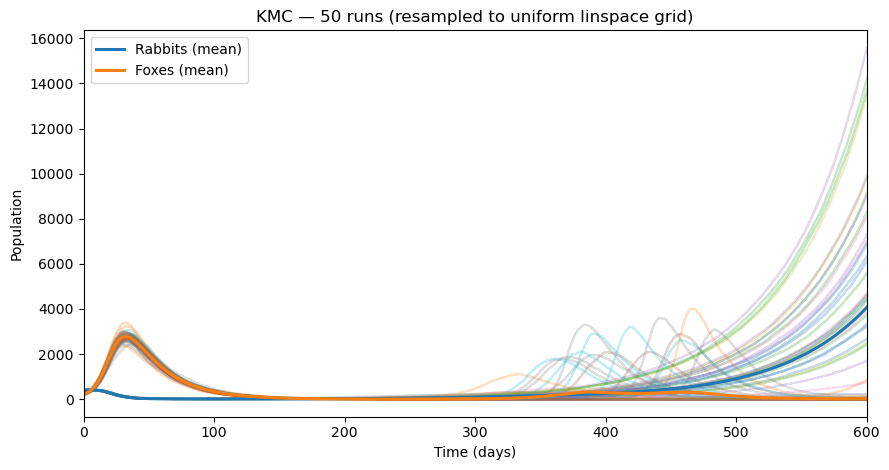

Run | Max Rabbits @ time | Max Foxes @ time
----+--------------------+-----------------
  1 |         410 @   4.00 |     2581 @  33.50
  2 |        2425 @ 600.00 |     2901 @  31.00
  3 |       15579 @ 600.00 |     2473 @  29.00
  4 |         431 @   8.00 |     2841 @  29.50
  5 |        9842 @ 600.00 |     3081 @  34.50
  6 |        2676 @ 600.00 |     2363 @  30.50
  7 |        9158 @ 600.00 |     2940 @  32.50
  8 |        7017 @ 600.00 |     2719 @  33.00
  9 |         477 @ 355.00 |     3305 @ 384.00
 10 |        2510 @ 600.00 |     2882 @  33.50
 11 |         495 @ 443.50 |     4019 @ 466.50
 12 |        4461 @ 600.00 |     2866 @  35.50
 13 |         416 @   7.00 |     2653 @  32.00
 14 |        4720 @ 600.00 |     2658 @  31.00
 15 |         495 @ 395.50 |     3217 @ 419.50
 16 |        6342 @ 600.00 |     2855 @  31.00
 17 |         413 @   5.50 |     2675 @  33.50
 18 |         412 @   5.50 |     2643 @  29.00
 19 |         417 @ 456.50 |     3103 @ 483.50
 20 |         411 @

In [67]:
# Plot all runs (light) + ensemble means (bold), and print max summaries

R_mean = R_grid.mean(axis=0)
F_mean = F_grid.mean(axis=0)

plt.figure(figsize=(9,4.8))
# light single-run traces to show variability
for i in range(N_RUNS):
    plt.step(times, R_grid[i], where="post", alpha=0.25)
    plt.step(times, F_grid[i], where="post", alpha=0.25)
# bold means
plt.plot(times, R_mean, linewidth=2.2, label="Rabbits (mean)")
plt.plot(times, F_mean, linewidth=2.2, label="Foxes (mean)")
plt.xlim(0, T_END)
plt.xlabel("Time (days)"); plt.ylabel("Population")
plt.title(f"KMC — {N_RUNS} runs (resampled to uniform linspace grid)")
plt.legend(); plt.tight_layout(); plt.show()

# per-run table + averages
print("Run | Max Rabbits @ time | Max Foxes @ time")
print("----+--------------------+-----------------")
for i in range(N_RUNS):
    print(f"{i+1:>3} | {maxR_vals[i]:>11} @ {maxR_times[i]:6.2f} | "
          f"{maxF_vals[i]:>8} @ {maxF_times[i]:6.2f}")

print("\nAverages over", N_RUNS, "runs:")
print(f"- Rabbits: avg max = {np.mean(maxR_vals):.2f}, avg time = {np.mean(maxR_times):.2f} d")
print(f"- Foxes:   avg max = {np.mean(maxF_vals):.2f}, avg time = {np.mean(maxF_times):.2f} d")


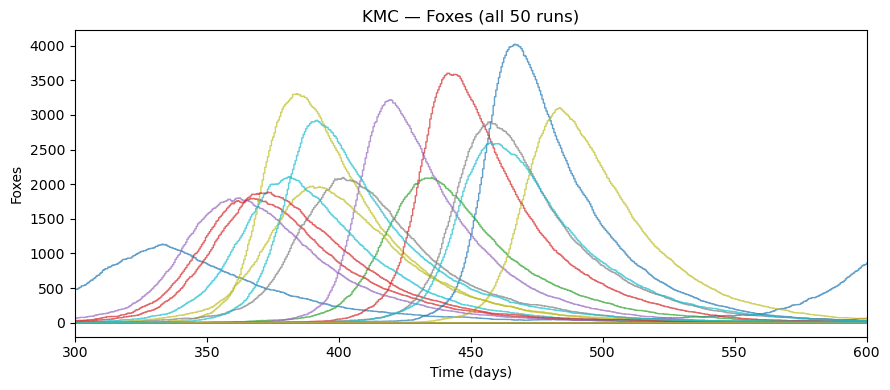

In [68]:
plt.figure(figsize=(9,4))

for i in range(N_RUNS):  # N_RUNS = 15
    plt.step(times, F_grid[i], where="post", linewidth=1.0, alpha=0.7)

plt.xlim(300, T_END)
plt.xlabel("Time (days)")
plt.ylabel("Foxes")
plt.title(f"KMC — Foxes (all {N_RUNS} runs)")
# no legend to keep it clean
plt.tight_layout()
plt.show()

Run  1: fox max in [300,600) = 1135 at t = 333.00 days
Run  2: fox max in [300,600) = 1 at t = 300.00 days
Run  3: fox max in [300,600) = 0 at t = 300.00 days
Run  4: fox max in [300,600) = 1795 at t = 367.50 days
Run  5: fox max in [300,600) = 4 at t = 306.50 days
Run  6: fox max in [300,600) = 0 at t = 300.00 days
Run  7: fox max in [300,600) = 0 at t = 300.00 days
Run  8: fox max in [300,600) = 0 at t = 300.00 days
Run  9: fox max in [300,600) = 3305 at t = 384.00 days
Run 10: fox max in [300,600) = 2 at t = 300.00 days
Run 11: fox max in [300,600) = 4019 at t = 466.50 days
Run 12: fox max in [300,600) = 0 at t = 300.00 days
Run 13: fox max in [300,600) = 2098 at t = 435.00 days
Run 14: fox max in [300,600) = 0 at t = 300.00 days
Run 15: fox max in [300,600) = 3217 at t = 419.50 days
Run 16: fox max in [300,600) = 0 at t = 300.00 days
Run 17: fox max in [300,600) = 0 at t = 300.00 days
Run 18: fox max in [300,600) = 2096 at t = 401.50 days
Run 19: fox max in [300,600) = 3103 at t = 

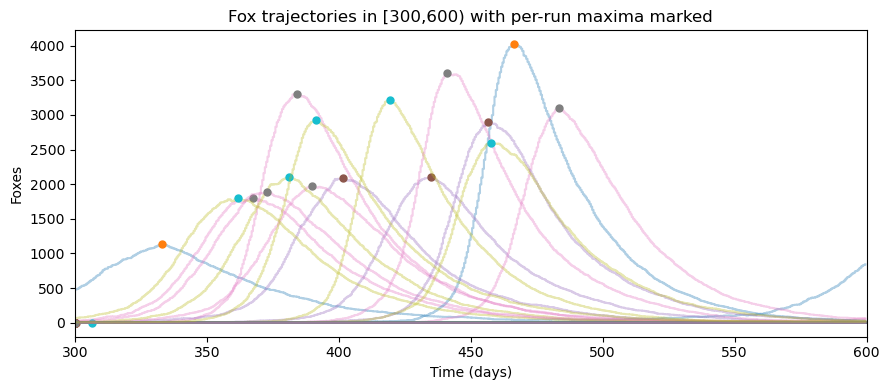

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# --- window ---
T_LO, T_HI = 300.0, 600.0
mask = (times >= T_LO) & (times < T_HI)
t_w = times[mask]

# --- per-run max in [300,600) ---
maxF_vals, maxF_times = [], []
idxs = []

for i in range(N_RUNS):
    F_w = F_grid[i, mask]
    if F_w.size == 0:
        maxF_vals.append(np.nan); maxF_times.append(np.nan); idxs.append(-1)
        continue
    j = int(np.argmax(F_w))
    maxF_vals.append(float(F_w[j]))
    maxF_times.append(float(t_w[j]))
    idxs.append(j)

# --- print results ---
for i, (v, t) in enumerate(zip(maxF_vals, maxF_times), 1):
    print(f"Run {i:2d}: fox max in [300,600) = {v:.0f} at t = {t:.2f} days")

print("\nAverages over runs (ignoring NaNs):")
print(f"value = {np.nanmean(maxF_vals):.2f},  time = {np.nanmean(maxF_times):.2f} days")

# --- plot only the window with markers at each run's max ---
plt.figure(figsize=(9,4))
for i in range(N_RUNS):
    plt.step(t_w, F_grid[i, mask], where="post", alpha=0.35)
    if idxs[i] != -1 and not np.isnan(maxF_vals[i]):
        plt.plot(maxF_times[i], maxF_vals[i], 'o', ms=5)

plt.xlim(T_LO, T_HI)
plt.xlabel("Time (days)")
plt.ylabel("Foxes")
plt.title(f"Fox trajectories in [{int(T_LO)},{int(T_HI)}) with per-run maxima marked")
plt.tight_layout()
plt.show()
